# 1 - Data Exploration

This notebook explores the Titled Tuesday dataset and prepares a leakage-safe pre-game feature view.

## Goals

- Validate data coverage and quality
- Build pre-game-only matchup features (White minus Black)
- Identify which features correlate with outcomes (`loss/draw/win` from White POV)
- Document known limitations and next-step feature ideas

## Leakage prevention

Only use information available before the game starts. Post-game fields (e.g., game moves/PGN, termination details, observed result fields as features) are excluded from modeling inputs.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_PATH = Path("../data/raw/titled_tuesday_games.jsonl")
assert DATA_PATH.exists(), f"Missing data file: {DATA_PATH}"

In [2]:
rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head(3)

Rows: 4,063
Columns: 18


,tournament_id,round,group,game_url,time_class,time_control,rated,rules,white_username,white_rating,white_result_raw,black_username,black_rating,black_result_raw,eco,start_time,end_time,result_white_pov
0,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787661,blitz,300,True,chess,UmutErdemGunduz,2682,timeout,Hikaru,3316,win,https://www.chess.com/openings/Modern-Defense-...,None,1770739793,loss
1,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787663,blitz,300,True,chess,lachesisQ,3279,win,GorinDeshi,2678,resigned,https://www.chess.com/openings/Sicilian-Defens...,None,1770739597,win
2,titled-tuesday-blitz-february-10-2026-6221327,0,0,https://www.chess.com/game/live/165052787665,blitz,300,True,chess,JaiSankarS,2677,checkmated,NikoTheodorou,3252,win,https://www.chess.com/openings/English-Opening...,None,1770739602,loss


## Target distribution

Check class balance before feature engineering/modeling. Draws are the minority class.

,count,share
result_white_pov,,
win,1951,0.480187
loss,1797,0.442284
draw,315,0.077529


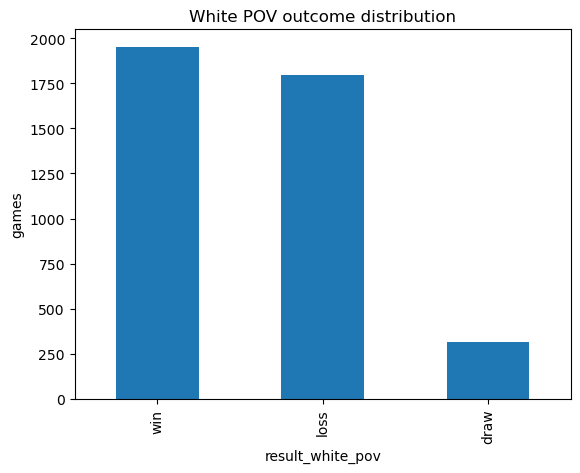

In [3]:
target_counts = df["result_white_pov"].value_counts(dropna=False)
target_props = df["result_white_pov"].value_counts(normalize=True, dropna=False)

display(target_counts.rename("count").to_frame().join(target_props.rename("share")))

target_counts.plot(kind="bar", title="White POV outcome distribution")
plt.ylabel("games")
plt.show()

## Base pre-game rating signal

Before adding richer features, inspect how outcome share moves with rating difference.

result_white_pov,draw,loss,win
rating_diff_bin,,,
"[-1000, -200)",0.060189,0.805675,0.134136
"[-200, -100)",0.106667,0.532000,0.361333
"[-100, -50)",0.024691,0.407407,0.567901
"[-50, 0)",0.111111,0.222222,0.666667
"[0, 50)",0.125000,0.437500,0.437500
"[50, 100)",0.126582,0.506329,0.367089
"[100, 200)",0.101064,0.305851,0.593085
"[200, 1000)",0.059916,0.117300,0.822785


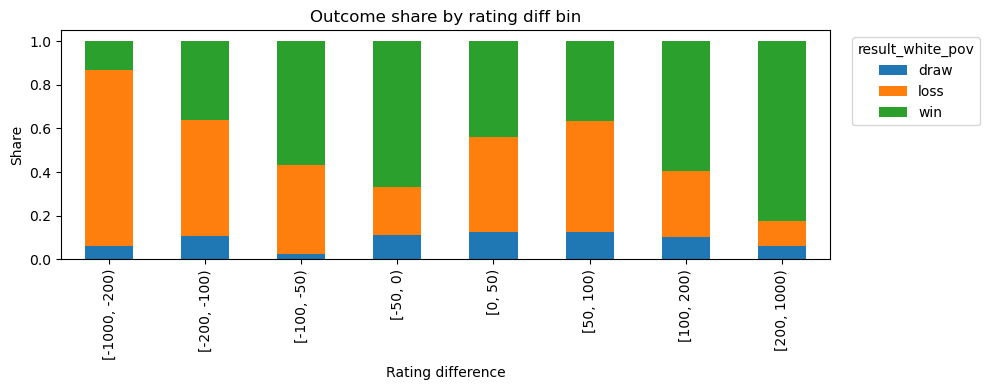

In [4]:
for c in ["white_rating", "black_rating", "round"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["rating_diff"] = df["white_rating"] - df["black_rating"]
df["average_rating"] = (df["white_rating"] + df["black_rating"]) / 2

bins = [-1000, -200, -100, -50, 0, 50, 100, 200, 1000]
labels = [f"[{bins[i]}, {bins[i+1]})" for i in range(len(bins)-1)]

df["rating_diff_bin"] = pd.cut(df["rating_diff"], bins=bins, labels=labels, right=False)

pivot = (
    df.groupby(["rating_diff_bin", "result_white_pov"], observed=False).size()
      .unstack(fill_value=0)
)

pivot_prop = pivot.div(pivot.sum(axis=1), axis=0)
display(pivot_prop)

pivot_prop.plot(kind="bar", stacked=True, figsize=(10, 4), title="Outcome share by rating diff bin")
plt.ylabel("Share")
plt.xlabel("Rating difference")
plt.legend(title="result_white_pov", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Leakage audit

These fields are generated during/after the game and must not be used as model inputs.

In [5]:
leakage_like = [
    "eco",
    "start_time",
    "end_time",
    "white_result_raw",
    "black_result_raw",
    "result_white_pov",
    "game_url",
]

existing_leakage_cols = [c for c in leakage_like if c in df.columns]
existing_leakage_cols

['eco',
 'start_time',
 'end_time',
 'white_result_raw',
 'black_result_raw',
 'result_white_pov',
 'game_url']

In [6]:
PLAYER_STATS_PATH = Path("../data/raw/titled_tuesday_players.jsonl")
assert PLAYER_STATS_PATH.exists(), f"Missing player stats file: {PLAYER_STATS_PATH}"

player_rows = []
with PLAYER_STATS_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        player_rows.append(json.loads(line))

player_stats_df = pd.DataFrame(player_rows)
print(f"Rows: {len(player_stats_df):,}")
print(f"Columns: {len(player_stats_df.columns)}")
player_stats_df.head(3)

Rows: 700
Columns: 6


,username,tournament_ids,profile,stats,profile_error,stats_error
0,7ChessAce,[titled-tuesday-blitz-february-10-2026-6221327...,"{'player_id': 521668111, '@id': 'https://api.c...","{'chess_bullet': {'last': {'rating': 2737, 'da...",None,None
1,A-Fier,[titled-tuesday-blitz-february-10-2026-6221327...,{'avatar': 'https://images.chesscomfiles.com/u...,"{'chess_daily': {'last': {'rating': 1663, 'dat...",None,None
2,ACH19,[titled-tuesday-blitz-february-10-2026-6221327...,{'avatar': 'https://images.chesscomfiles.com/u...,"{'chess_daily': {'last': {'rating': 1727, 'dat...",None,None


In [7]:
player_stats_df.stats[0]

{'chess_bullet': {'last': {'rating': 2737, 'date': 1776992903, 'rd': 45},
  'best': {'rating': 2755,
   'date': 1772425175,
   'game': 'https://www.chess.com/game/live/166615212345'},
  'record': {'win': 111, 'loss': 68, 'draw': 12}},
 'chess_blitz': {'last': {'rating': 2904, 'date': 1776988636, 'rd': 31},
  'best': {'rating': 2904,
   'date': 1776988636,
   'game': 'https://www.chess.com/game/live/167698523714'},
  'record': {'win': 198, 'loss': 101, 'draw': 32}},
 'fide': 2387,
 'tactics': {'highest': {'rating': 2417, 'date': 1776493688},
  'lowest': {'rating': 400, 'date': 1769023243}},
 'puzzle_rush': {}}

In [8]:
df.columns

Index(['tournament_id', 'round', 'group', 'game_url', 'time_class', 'time_control', 'rated', 'rules', 'white_username', 'white_rating',
       'white_result_raw', 'black_username', 'black_rating', 'black_result_raw', 'eco', 'start_time', 'end_time', 'result_white_pov',
       'rating_diff', 'average_rating', 'rating_diff_bin'],
      dtype='str')

In [9]:
TIME_CLASS_TO_STATS_KEY = {
    "bullet": "chess_bullet",
    "blitz": "chess_blitz",
    "rapid": "chess_rapid",
    "daily": "chess_daily",
}


def _safe_div(numerator, denominator):
    if numerator is None or pd.isna(numerator):
        return np.nan
    if denominator in (0, None) or pd.isna(denominator):
        return np.nan
    return numerator / denominator


def build_player_timeclass_features(players_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in players_df.iterrows():
        username = row.get("username")
        stats = row.get("stats") or {}
        profile = row.get("profile") or {}
        tournament_ids = row.get("tournament_ids") or []

        base = {
            "username": username,
            "username_key": str(username).lower() if pd.notna(username) else None,
            "tournament_count": len(tournament_ids),
            "account_age_joined_ts": profile.get("joined"),
            "follower_count": profile.get("followers"),
            "title": profile.get("title"),
            "fide": stats.get("fide"),
        }

        tournament_stats = stats.get("tournament") or {}
        tournament_points = tournament_stats.get("points")
        tournament_withdraw = tournament_stats.get("withdraw")
        tournament_highest_finish = tournament_stats.get("highest_finish")

        base.update(
            {
                "tournament_points": tournament_points,
                "tournament_highest_finish": tournament_highest_finish,
                "points_per_tournament": _safe_div(tournament_points, len(tournament_ids)),
                "withdrawal_rate": _safe_div(tournament_withdraw, len(tournament_ids)),
            }
        )

        for stats_key in TIME_CLASS_TO_STATS_KEY.values():
            tc_stats = stats.get(stats_key)
            if not isinstance(tc_stats, dict) or len(tc_stats) == 0:
                continue

            last = tc_stats.get("last") or {}
            best = tc_stats.get("best") or {}
            record = tc_stats.get("record") or {}

            wins = record.get("win", 0)
            losses = record.get("loss", 0)
            draws = record.get("draw", 0)
            total_games = wins + losses + draws

            current_rating = last.get("rating")
            peak_rating = best.get("rating")

            rows.append(
                {
                    **base,
                    "stats_key": stats_key,
                    "current_rating": current_rating,
                    "current_rating_rd": last.get("rd"),
                    "current_rating_ts": last.get("date"),
                    "peak_rating": peak_rating,
                    "peak_rating_ts": best.get("date"),
                    "rating_trend_from_peak": (
                        current_rating - peak_rating
                        if pd.notna(current_rating) and pd.notna(peak_rating)
                        else np.nan
                    ),
                    "wins": wins,
                    "losses": losses,
                    "draws": draws,
                    "games_played": total_games,
                    "win_rate": _safe_div(wins, total_games),
                    "loss_rate": _safe_div(losses, total_games),
                    "draw_rate": _safe_div(draws, total_games),
                    "draw_tendency": _safe_div(draws, total_games),
                    "timeout_percent": tc_stats.get("timeout_percent"),
                    "time_per_move": tc_stats.get("time_per_move"),
                }
            )

    return pd.DataFrame(rows)


player_tc_features = build_player_timeclass_features(player_stats_df)
print(f"Per-player/per-time-class rows: {len(player_tc_features):,}")
player_tc_features.head(3)


games_with_features = df.copy()
games_with_features["stats_key"] = games_with_features["time_class"].map(TIME_CLASS_TO_STATS_KEY)
games_with_features["white_username_key"] = games_with_features["white_username"].str.lower()
games_with_features["black_username_key"] = games_with_features["black_username"].str.lower()

white_features = player_tc_features.add_prefix("white_")
black_features = player_tc_features.add_prefix("black_")

games_with_features = games_with_features.merge(
    white_features,
    left_on=["white_username_key", "stats_key"],
    right_on=["white_username_key", "white_stats_key"],
    how="left",
)

games_with_features = games_with_features.merge(
    black_features,
    left_on=["black_username_key", "stats_key"],
    right_on=["black_username_key", "black_stats_key"],
    how="left",
)

# Matchup deltas (white minus black)
games_with_features["rating_delta"] = (
    games_with_features["white_current_rating"] - games_with_features["black_current_rating"]
)
games_with_features["rd_delta"] = (
    games_with_features["white_current_rating_rd"] - games_with_features["black_current_rating_rd"]
)
games_with_features["peak_rating_delta"] = (
    games_with_features["white_peak_rating"] - games_with_features["black_peak_rating"]
)
games_with_features["rating_trend_delta"] = (
    games_with_features["white_rating_trend_from_peak"] - games_with_features["black_rating_trend_from_peak"]
)
games_with_features["win_rate_delta"] = (
    games_with_features["white_win_rate"] - games_with_features["black_win_rate"]
)
games_with_features["draw_rate_delta"] = (
    games_with_features["white_draw_rate"] - games_with_features["black_draw_rate"]
)
games_with_features["timeout_percent_delta"] = (
    games_with_features["white_timeout_percent"] - games_with_features["black_timeout_percent"]
)
games_with_features["time_per_move_delta"] = (
    games_with_features["white_time_per_move"] - games_with_features["black_time_per_move"]
)
games_with_features["tournament_count_delta"] = (
    games_with_features["white_tournament_count"] - games_with_features["black_tournament_count"]
)
games_with_features["points_per_tournament_delta"] = (
    games_with_features["white_points_per_tournament"] - games_with_features["black_points_per_tournament"]
)
games_with_features["withdrawal_rate_delta"] = (
    games_with_features["white_withdrawal_rate"] - games_with_features["black_withdrawal_rate"]
)

# Additional absolute and delta features available from already-loaded stats/profile payloads.
games_with_features["white_advantage_prior"] = 1.0
games_with_features["fide_delta"] = games_with_features["white_fide"] - games_with_features["black_fide"]
games_with_features["follower_count_delta"] = (
    games_with_features["white_follower_count"] - games_with_features["black_follower_count"]
)
games_with_features["account_age_joined_ts_delta"] = (
    games_with_features["white_account_age_joined_ts"] - games_with_features["black_account_age_joined_ts"]
)
games_with_features["games_played_delta"] = games_with_features["white_games_played"] - games_with_features["black_games_played"]
games_with_features["wins_delta"] = games_with_features["white_wins"] - games_with_features["black_wins"]
games_with_features["losses_delta"] = games_with_features["white_losses"] - games_with_features["black_losses"]
games_with_features["draws_delta"] = games_with_features["white_draws"] - games_with_features["black_draws"]
games_with_features["current_rating_abs_diff"] = games_with_features["rating_delta"].abs()
games_with_features["current_rating_rd_abs_diff"] = games_with_features["rd_delta"].abs()
games_with_features["title_any_white"] = games_with_features["white_title"].notna().astype(int)
games_with_features["title_any_black"] = games_with_features["black_title"].notna().astype(int)
games_with_features["title_delta"] = (
    games_with_features["title_any_white"] - games_with_features["title_any_black"]
)

# Preserve canonical username columns after merges (pandas may suffix duplicates).
if "white_username" not in games_with_features.columns:
    for candidate in ["white_username_x", "white_username_y"]:
        if candidate in games_with_features.columns:
            games_with_features["white_username"] = games_with_features[candidate]
            break

if "black_username" not in games_with_features.columns:
    for candidate in ["black_username_x", "black_username_y"]:
        if candidate in games_with_features.columns:
            games_with_features["black_username"] = games_with_features[candidate]
            break

feature_cols = [
    "white_username",
    "black_username",
    "time_class",
    "result_white_pov",
    "white_advantage_prior",
    "rating_delta",
    "current_rating_abs_diff",
    "rd_delta",
    "current_rating_rd_abs_diff",
    "peak_rating_delta",
    "rating_trend_delta",
    "games_played_delta",
    "wins_delta",
    "losses_delta",
    "draws_delta",
    "win_rate_delta",
    "draw_rate_delta",
    "timeout_percent_delta",
    "time_per_move_delta",
    "tournament_count_delta",
    "points_per_tournament_delta",
    "withdrawal_rate_delta",
    "fide_delta",
    "follower_count_delta",
    "account_age_joined_ts_delta",
    "title_delta",
]

model_df = games_with_features[feature_cols].copy()
print(f"Model rows: {len(model_df):,}")
model_df.head(5)

# H2H, recency/form, opening-prep and color-specific performance features
# require monthly archive game history and PGN parsing; add after archive ingestion.

Per-player/per-time-class rows: 2,316
Model rows: 4,063


,white_username,black_username,time_class,result_white_pov,white_advantage_prior,rating_delta,current_rating_abs_diff,rd_delta,current_rating_rd_abs_diff,peak_rating_delta,rating_trend_delta,games_played_delta,wins_delta,losses_delta,draws_delta,win_rate_delta,draw_rate_delta,timeout_percent_delta,time_per_move_delta,tournament_count_delta,points_per_tournament_delta,withdrawal_rate_delta,fide_delta,follower_count_delta,account_age_joined_ts_delta,title_delta
0,UmutErdemGunduz,Hikaru,blitz,loss,1.0,-721,721,11.0,11.0,-667.0,-54.0,-42290,-33379,-4803,-4108,-0.224149,-0.008193,NaN,NaN,0,NaN,NaN,-427.0,-1385903,173742837,0
1,lachesisQ,GorinDeshi,blitz,win,1.0,541,541,-5.0,5.0,627.0,-86.0,7472,4366,2034,1072,0.079530,0.086941,NaN,NaN,0,NaN,NaN,NaN,16924,-227011256,0
2,JaiSankarS,NikoTheodorou,blitz,loss,1.0,-556,556,12.0,12.0,-596.0,40.0,-8675,-4234,-3196,-1245,-0.050580,-0.018395,NaN,NaN,0,NaN,NaN,NaN,-13975,129499917,0
3,GMWSO,GCamachoMartinez,blitz,loss,1.0,622,622,8.0,8.0,576.0,46.0,-2260,-585,-1632,-43,0.109787,0.055284,NaN,NaN,0,NaN,NaN,NaN,10776,-34201545,0
4,dey2580,GHANDEEVAM2003,blitz,loss,1.0,-565,565,-3.0,3.0,-534.0,-31.0,-8077,-4483,-2597,-997,-0.032271,-0.036208,NaN,NaN,0,NaN,NaN,-390.0,-5589,96337864,0


In [10]:
model_df.columns

Index(['white_username', 'black_username', 'time_class', 'result_white_pov', 'white_advantage_prior', 'rating_delta',
       'current_rating_abs_diff', 'rd_delta', 'current_rating_rd_abs_diff', 'peak_rating_delta', 'rating_trend_delta',
       'games_played_delta', 'wins_delta', 'losses_delta', 'draws_delta', 'win_rate_delta', 'draw_rate_delta', 'timeout_percent_delta',
       'time_per_move_delta', 'tournament_count_delta', 'points_per_tournament_delta', 'withdrawal_rate_delta', 'fide_delta',
       'follower_count_delta', 'account_age_joined_ts_delta', 'title_delta'],
      dtype='str')

In [11]:
# Prepare modeling view for correlation analysis.
model_vis_df = model_df.copy()

# Encode outcomes from White's perspective.
outcome_to_score = {"loss": 0.0, "draw": 0.5, "win": 1.0}
model_vis_df["white_score"] = model_vis_df["result_white_pov"].map(outcome_to_score)
model_vis_df["white_win"] = (model_vis_df["result_white_pov"] == "win").astype(int)

numeric_feature_cols = [
    c
    for c in model_vis_df.columns
    if c not in [
        "white_username",
        "black_username",
        "time_class",
        "result_white_pov",
        "white_score",
        "white_win",
    ]
    and pd.api.types.is_numeric_dtype(model_vis_df[c])
]

corr_target = (
    model_vis_df[numeric_feature_cols + ["white_score", "white_win"]]
    .corr(numeric_only=True)
    [["white_score", "white_win"]]
    .sort_values("white_score", ascending=False)
)

print("Numeric features:", len(numeric_feature_cols))
corr_target.head(20)

Numeric features: 20


,white_score,white_win
white_score,1.000000,0.963524
white_win,0.963524,1.000000
rating_delta,0.530967,0.510386
peak_rating_delta,0.520864,0.500556
win_rate_delta,0.291578,0.282307
draw_rate_delta,0.238904,0.236784
draws_delta,0.139212,0.138182
wins_delta,0.129603,0.127810
games_played_delta,0.105724,0.105051
fide_delta,0.082022,0.076006


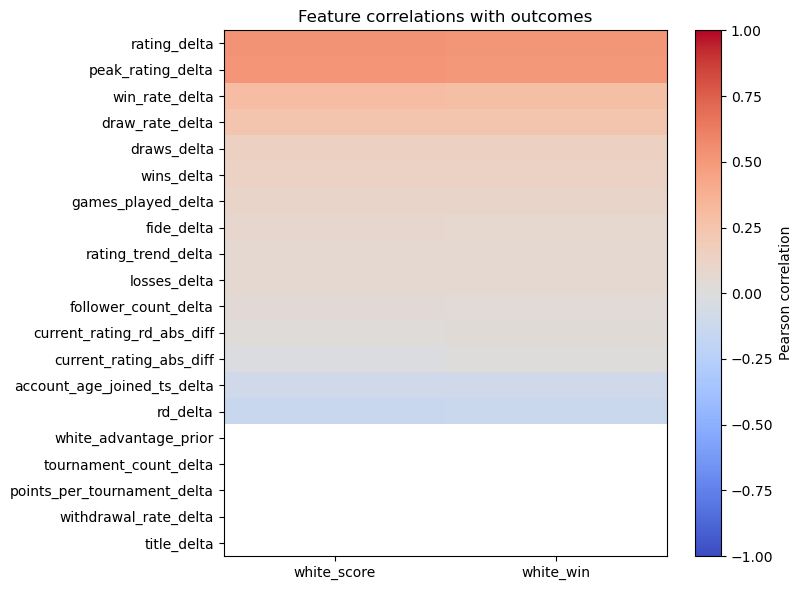

,white_score,white_win
rating_delta,0.530967,0.510386
peak_rating_delta,0.520864,0.500556
win_rate_delta,0.291578,0.282307
draw_rate_delta,0.238904,0.236784
draws_delta,0.139212,0.138182
wins_delta,0.129603,0.127810
games_played_delta,0.105724,0.105051
fide_delta,0.082022,0.076006
rating_trend_delta,0.058860,0.056962
losses_delta,0.057340,0.058268


In [12]:
# Heatmap: feature correlations with white_score / white_win.
target_cols = ["white_score", "white_win"]
feature_corr = corr_target.drop(index=target_cols, errors="ignore").copy()
feature_corr = feature_corr[target_cols]

fig, ax = plt.subplots(figsize=(8, max(6, 0.3 * len(feature_corr))))
im = ax.imshow(feature_corr.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(target_cols)))
ax.set_xticklabels(target_cols)
ax.set_yticks(np.arange(len(feature_corr.index)))
ax.set_yticklabels(feature_corr.index)
ax.set_title("Feature correlations with outcomes")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation")

plt.tight_layout()
plt.show()

feature_corr

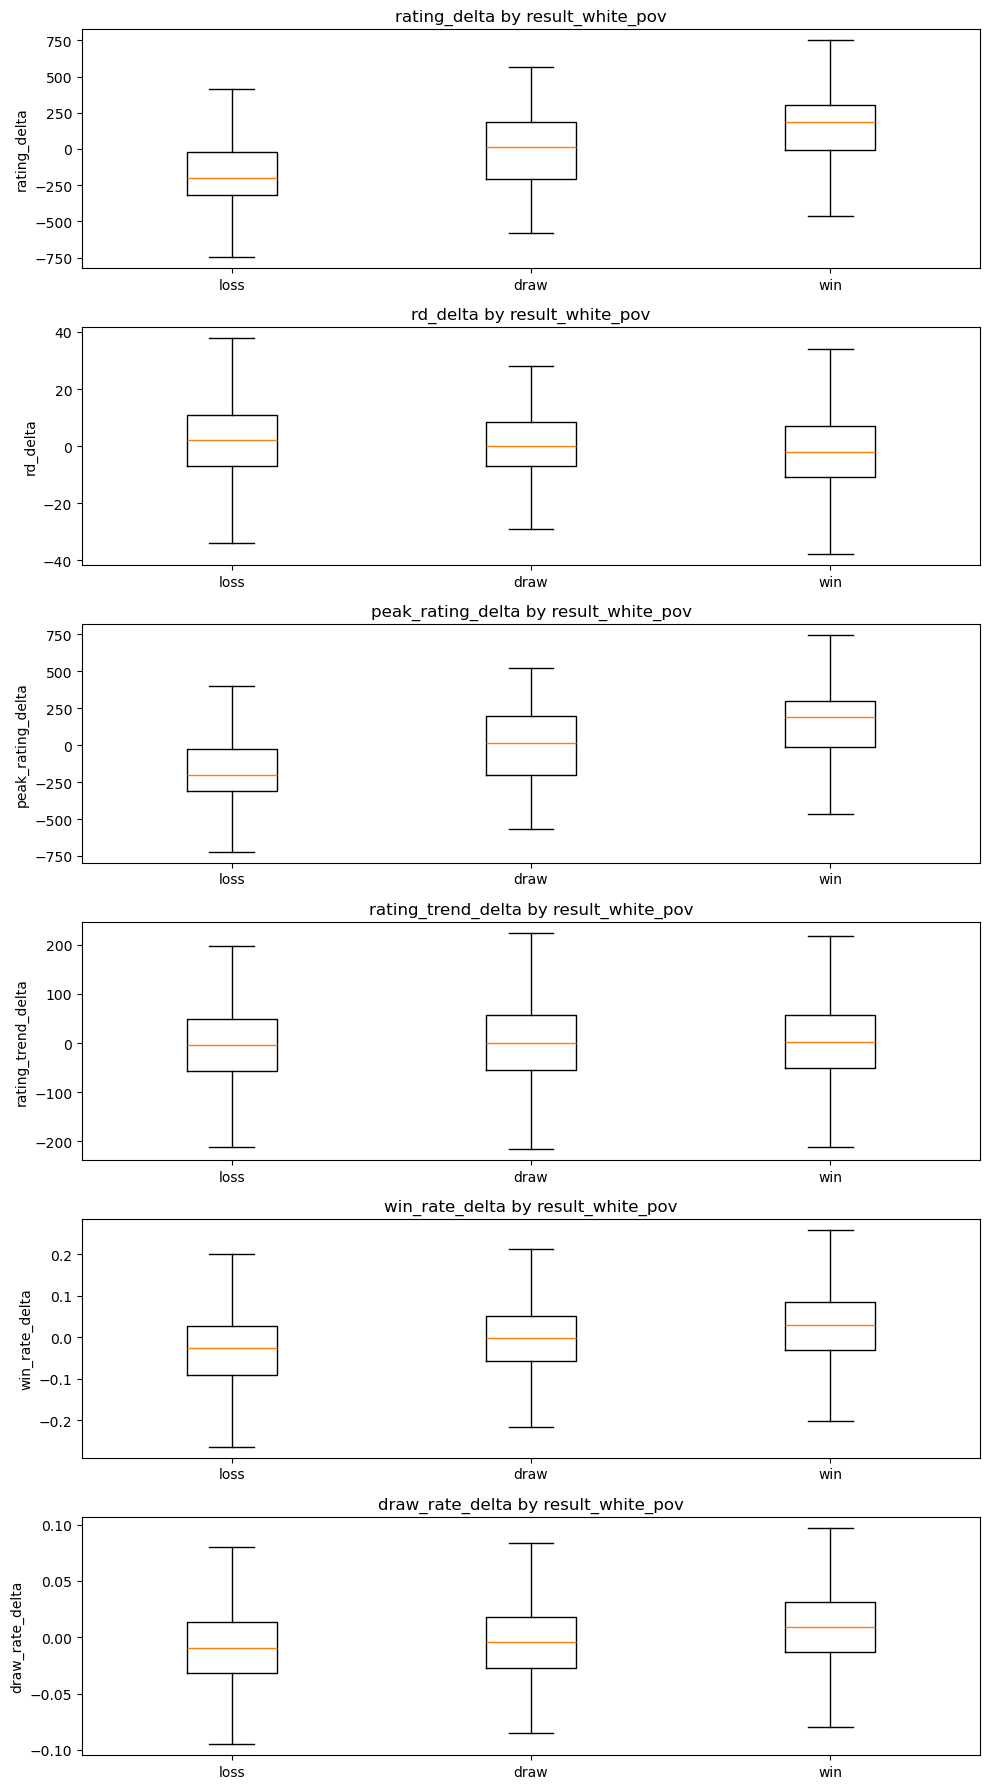

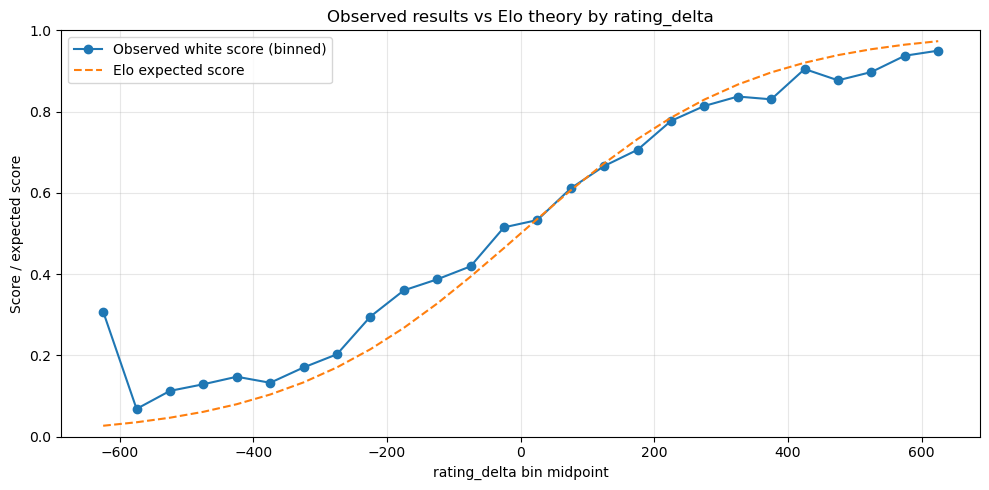

,rating_bin,bin_mid,white_score_mean,white_win_mean,elo_expected_score,count
19,"(150, 200]",175.0,0.706061,0.651515,0.732507,330
20,"(200, 250]",225.0,0.777027,0.739865,0.785027,296
21,"(250, 300]",275.0,0.813910,0.778195,0.829633,266
22,"(300, 350]",325.0,0.837017,0.801105,0.866557,181
23,"(350, 400]",375.0,0.830189,0.811321,0.896477,159
24,"(400, 450]",425.0,0.904762,0.869048,0.920305,84
25,"(450, 500]",475.0,0.876923,0.861538,0.939022,65
26,"(500, 550]",525.0,0.897436,0.897436,0.953565,39
27,"(550, 600]",575.0,0.937500,0.916667,0.964769,24
28,"(600, 650]",625.0,0.950000,0.950000,0.973346,20


In [13]:
# Visual diagnostics for top signals.
focus_features = [
    "rating_delta",
    "rd_delta",
    "peak_rating_delta",
    "rating_trend_delta",
    "win_rate_delta",
    "draw_rate_delta",
]

available_focus = [c for c in focus_features if c in model_vis_df.columns]

# Boxplots by result class (distribution shifts).
fig, axes = plt.subplots(nrows=len(available_focus), ncols=1, figsize=(10, 3 * len(available_focus)), sharex=False)
if len(available_focus) == 1:
    axes = [axes]

for ax, col in zip(axes, available_focus):
    box_data = [
        model_vis_df.loc[model_vis_df["result_white_pov"] == label, col].dropna()
        for label in ["loss", "draw", "win"]
    ]
    ax.boxplot(box_data, tick_labels=["loss", "draw", "win"], showfliers=False)
    ax.set_title(f"{col} by result_white_pov")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

# Binned trend vs rating_delta with Elo-theory overlay.
bins = np.arange(-800, 825, 50)
tmp = model_vis_df[["rating_delta", "white_score", "white_win"]].dropna().copy()
tmp["rating_bin"] = pd.cut(tmp["rating_delta"], bins=bins)

trend = (
    tmp.groupby("rating_bin", observed=False)[["white_score", "white_win"]]
    .agg(["mean", "count"])
    .reset_index()
)
trend.columns = [
    "rating_bin",
    "white_score_mean",
    "white_score_count",
    "white_win_mean",
    "white_win_count",
]
trend["count"] = trend[["white_score_count", "white_win_count"]].min(axis=1)
trend = trend[trend["count"] >= 10].copy()

# Convert interval bins to numeric midpoints (avoid categorical arithmetic errors).
interval_to_mid = {
    interval: float((interval.left + interval.right) / 2)
    for interval in trend["rating_bin"].cat.categories
}
trend["bin_mid"] = trend["rating_bin"].map(interval_to_mid).astype(float)

# Elo expected score for White given rating difference.
trend["elo_expected_score"] = 1.0 / (1.0 + 10.0 ** (-trend["bin_mid"] / 400.0))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(trend["bin_mid"], trend["white_score_mean"], marker="o", label="Observed white score (binned)")
ax1.plot(trend["bin_mid"], trend["elo_expected_score"], linestyle="--", label="Elo expected score")
ax1.set_xlabel("rating_delta bin midpoint")
ax1.set_ylabel("Score / expected score")
ax1.set_title("Observed results vs Elo theory by rating_delta")
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)
ax1.legend()

plt.tight_layout()
plt.show()

trend[["rating_bin", "bin_mid", "white_score_mean", "white_win_mean", "elo_expected_score", "count"]].tail(10)

In [14]:
# Additional targeted diagnostics below focus on rating uncertainty (RD), calibration,
# and residual structure beyond Elo expectation.

In [15]:
# RD vs volatility: define surprise relative to Elo expectation.
rd_vol_df = model_vis_df[["rating_delta", "white_score", "rd_delta", "current_rating_rd_abs_diff"]].copy()
rd_vol_df["white_rd"] = games_with_features["white_current_rating_rd"].values
rd_vol_df["black_rd"] = games_with_features["black_current_rating_rd"].values
rd_vol_df["rd_mean"] = rd_vol_df[["white_rd", "black_rd"]].mean(axis=1)
rd_vol_df["rd_max"] = rd_vol_df[["white_rd", "black_rd"]].max(axis=1)

# Elo expected score from rating difference.
rd_vol_df["elo_expected_score"] = 1.0 / (1.0 + 10.0 ** (-rd_vol_df["rating_delta"] / 400.0))

# Volatility proxies: absolute surprise and squared surprise.
rd_vol_df["abs_surprise"] = (rd_vol_df["white_score"] - rd_vol_df["elo_expected_score"]).abs()
rd_vol_df["sq_surprise"] = (rd_vol_df["white_score"] - rd_vol_df["elo_expected_score"]) ** 2

rd_cols = ["white_rd", "black_rd", "rd_mean", "rd_max", "rd_delta", "current_rating_rd_abs_diff"]
rd_corr = (
    rd_vol_df[rd_cols + ["abs_surprise", "sq_surprise"]]
    .corr(numeric_only=True)
    [["abs_surprise", "sq_surprise"]]
    .sort_values("abs_surprise", ascending=False)
)

print("Rows for RD-volatility analysis:", len(rd_vol_df.dropna(subset=["rd_mean", "abs_surprise"])))
rd_corr

Rows for RD-volatility analysis: 4063


,abs_surprise,sq_surprise
abs_surprise,1.000000,0.969086
sq_surprise,0.969086,1.000000
rd_delta,0.016740,0.017618
white_rd,0.000877,0.010064
current_rating_rd_abs_diff,-0.010248,0.001941
rd_mean,-0.014855,-0.003146
rd_max,-0.015827,-0.001390
black_rd,-0.022006,-0.014269


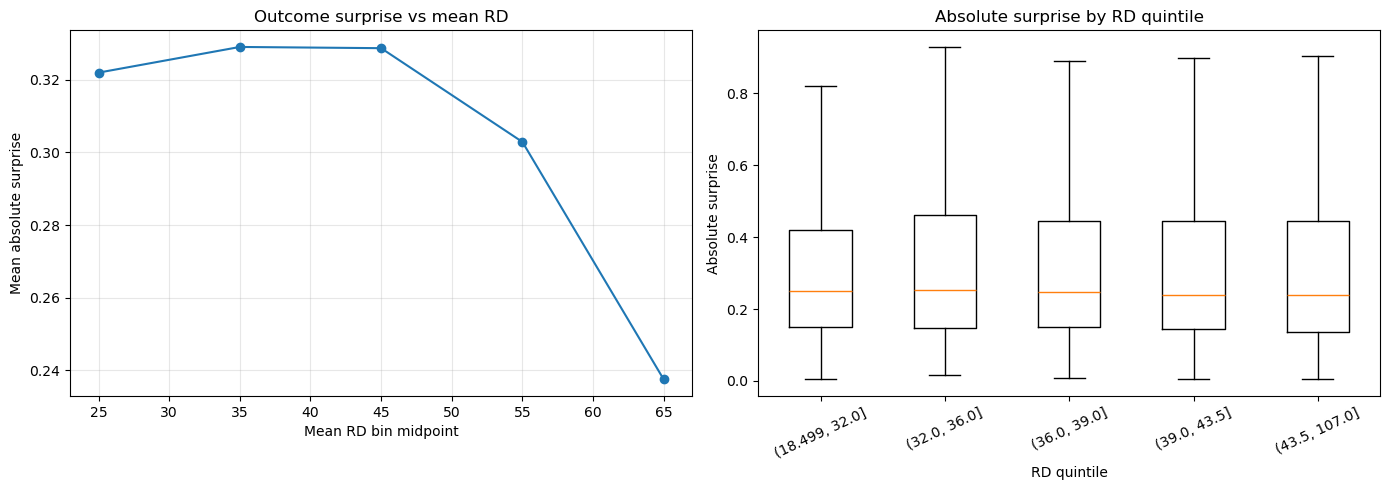

(  rd_mean_bin      mean  count  bin_mid
 2    (20, 30]  0.321978    568     25.0
 3    (30, 40]  0.329047   2110     35.0
 4    (40, 50]  0.328711   1173     45.0
 5    (50, 60]  0.302899    157     55.0
 6    (60, 70]  0.237525     40     65.0,
   rd_mean_quintile      mean    median  count
 0   (18.499, 32.0]  0.321421  0.250917    863
 1     (32.0, 36.0]  0.332435  0.254177    878
 2     (36.0, 39.0]  0.332680  0.248759    715
 3     (39.0, 43.5]  0.322161  0.238681    844
 4    (43.5, 107.0]  0.323290  0.239204    763)

In [16]:
# Visualize volatility vs RD level.
plot_df = rd_vol_df.dropna(subset=["rd_mean", "abs_surprise"]).copy()

# 1) Binned curve: mean RD vs mean surprise.
rd_bins = np.arange(0, 260, 10)
plot_df["rd_mean_bin"] = pd.cut(plot_df["rd_mean"], bins=rd_bins)
rd_trend = plot_df.groupby("rd_mean_bin", observed=False)["abs_surprise"].agg(["mean", "count"]).reset_index()
rd_trend = rd_trend[rd_trend["count"] >= 15].copy()

interval_to_mid = {
    interval: float((interval.left + interval.right) / 2)
    for interval in rd_trend["rd_mean_bin"].cat.categories
}
rd_trend["bin_mid"] = rd_trend["rd_mean_bin"].map(interval_to_mid).astype(float)

# 2) Quantile view: volatility by RD quintile.
plot_df["rd_mean_quintile"] = pd.qcut(plot_df["rd_mean"], q=5, duplicates="drop")
q_summary = (
    plot_df.groupby("rd_mean_quintile", observed=False)["abs_surprise"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(rd_trend["bin_mid"], rd_trend["mean"], marker="o")
ax1.set_xlabel("Mean RD bin midpoint")
ax1.set_ylabel("Mean absolute surprise")
ax1.set_title("Outcome surprise vs mean RD")
ax1.grid(alpha=0.3)

box_data = [
    plot_df.loc[plot_df["rd_mean_quintile"] == bucket, "abs_surprise"].dropna()
    for bucket in q_summary["rd_mean_quintile"]
]
ax2.boxplot(box_data, tick_labels=[str(b) for b in q_summary["rd_mean_quintile"]], showfliers=False)
ax2.set_title("Absolute surprise by RD quintile")
ax2.set_xlabel("RD quintile")
ax2.set_ylabel("Absolute surprise")
ax2.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

rd_trend.tail(10), q_summary

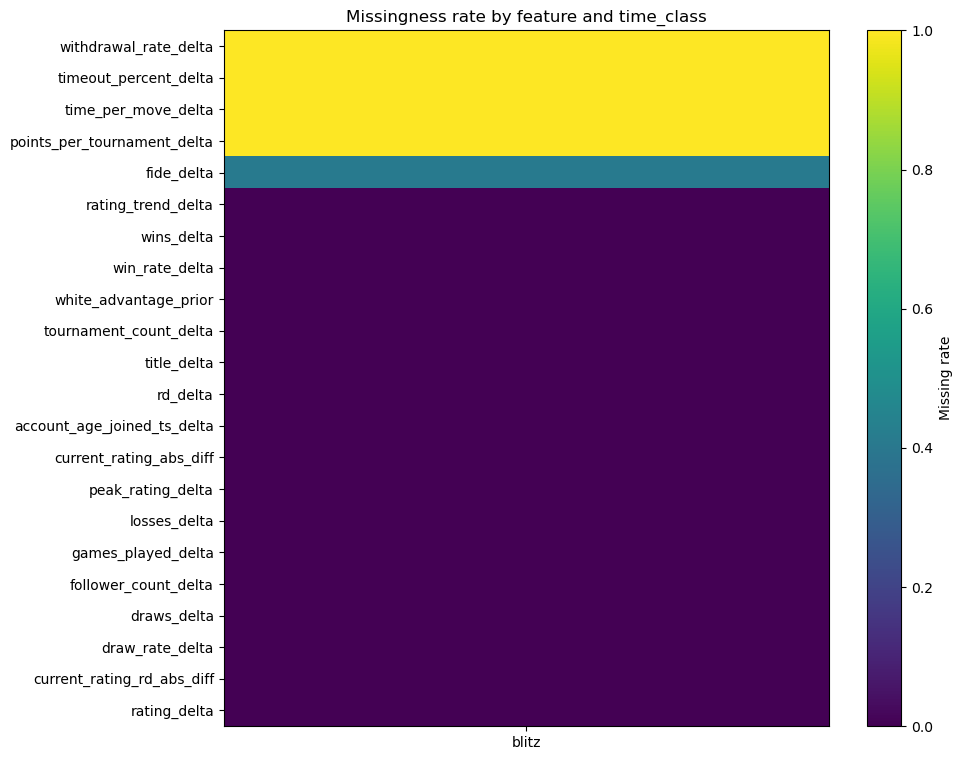

time_class,blitz,overall_missing_rate
feature,,
withdrawal_rate_delta,1.000000,1.000000
timeout_percent_delta,1.000000,1.000000
time_per_move_delta,1.000000,1.000000
points_per_tournament_delta,1.000000,1.000000
fide_delta,0.411519,0.411519
rating_trend_delta,0.000000,0.000000
wins_delta,0.000000,0.000000
win_rate_delta,0.000000,0.000000
white_advantage_prior,0.000000,0.000000


In [17]:
# 1) Missingness audit by feature and time class.
non_feature_cols = ["white_username", "black_username", "time_class", "result_white_pov"]
feature_cols_only = [c for c in model_df.columns if c not in non_feature_cols]

missing_by_time_class = (
    model_df.groupby("time_class", dropna=False)[feature_cols_only]
    .apply(lambda g: g.isna().mean())
    .reset_index()
)

missing_long = missing_by_time_class.melt(
    id_vars="time_class", var_name="feature", value_name="missing_rate"
)
missing_pivot = missing_long.pivot(index="feature", columns="time_class", values="missing_rate").fillna(0.0)

# Sort by overall missingness for readability.
missing_pivot["overall_missing_rate"] = model_df[feature_cols_only].isna().mean()
missing_pivot = missing_pivot.sort_values("overall_missing_rate", ascending=False)

plot_mat = missing_pivot.drop(columns=["overall_missing_rate"]).copy()

fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(plot_mat))))
im = ax.imshow(plot_mat.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(plot_mat.columns)))
ax.set_xticklabels(plot_mat.columns)
ax.set_yticks(np.arange(len(plot_mat.index)))
ax.set_yticklabels(plot_mat.index)
ax.set_title("Missingness rate by feature and time_class")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Missing rate")

plt.tight_layout()
plt.show()

missing_pivot.head(20)

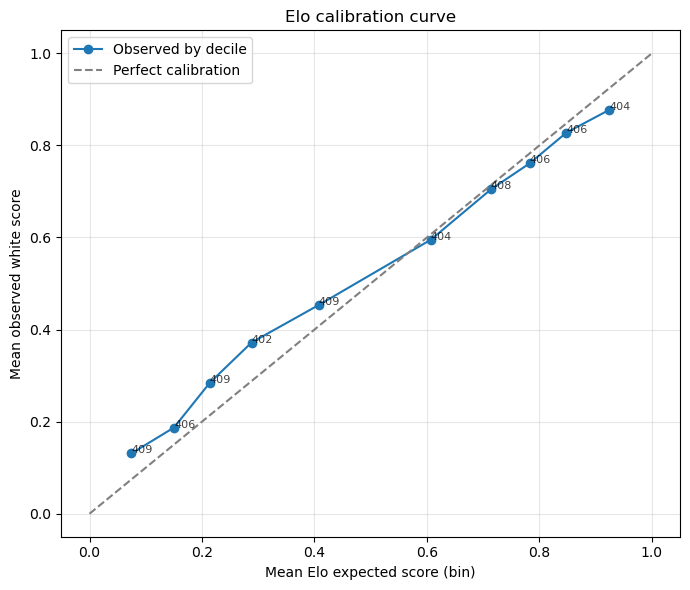

,elo_bin,expected_score,observed_score,count
0,"(0.00358, 0.115]",0.074339,0.130807,409
1,"(0.115, 0.183]",0.150247,0.187192,406
2,"(0.183, 0.247]",0.214171,0.284841,409
3,"(0.247, 0.33]",0.288183,0.371891,402
4,"(0.33, 0.506]",0.407934,0.453545,409
5,"(0.506, 0.674]",0.607088,0.595297,404
6,"(0.674, 0.75]",0.713907,0.704657,408
7,"(0.75, 0.815]",0.782686,0.761084,406
8,"(0.815, 0.883]",0.847790,0.827586,406
9,"(0.883, 0.996]",0.924561,0.877475,404


In [18]:
# 2) Elo calibration: expected score deciles vs observed score.
calib_df = model_vis_df[["rating_delta", "white_score", "time_class"]].dropna().copy()
calib_df["elo_expected_score"] = 1.0 / (1.0 + 10.0 ** (-calib_df["rating_delta"] / 400.0))
calib_df["elo_bin"] = pd.qcut(calib_df["elo_expected_score"], q=10, duplicates="drop")

calib_summary = (
    calib_df.groupby("elo_bin", observed=False)
    .agg(
        expected_score=("elo_expected_score", "mean"),
        observed_score=("white_score", "mean"),
        count=("white_score", "size"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(calib_summary["expected_score"], calib_summary["observed_score"], marker="o", label="Observed by decile")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean Elo expected score (bin)")
ax.set_ylabel("Mean observed white score")
ax.set_title("Elo calibration curve")
ax.grid(alpha=0.3)
ax.legend()

for _, r in calib_summary.iterrows():
    ax.annotate(str(int(r["count"])), (r["expected_score"], r["observed_score"]), fontsize=8, alpha=0.75)

plt.tight_layout()
plt.show()

calib_summary

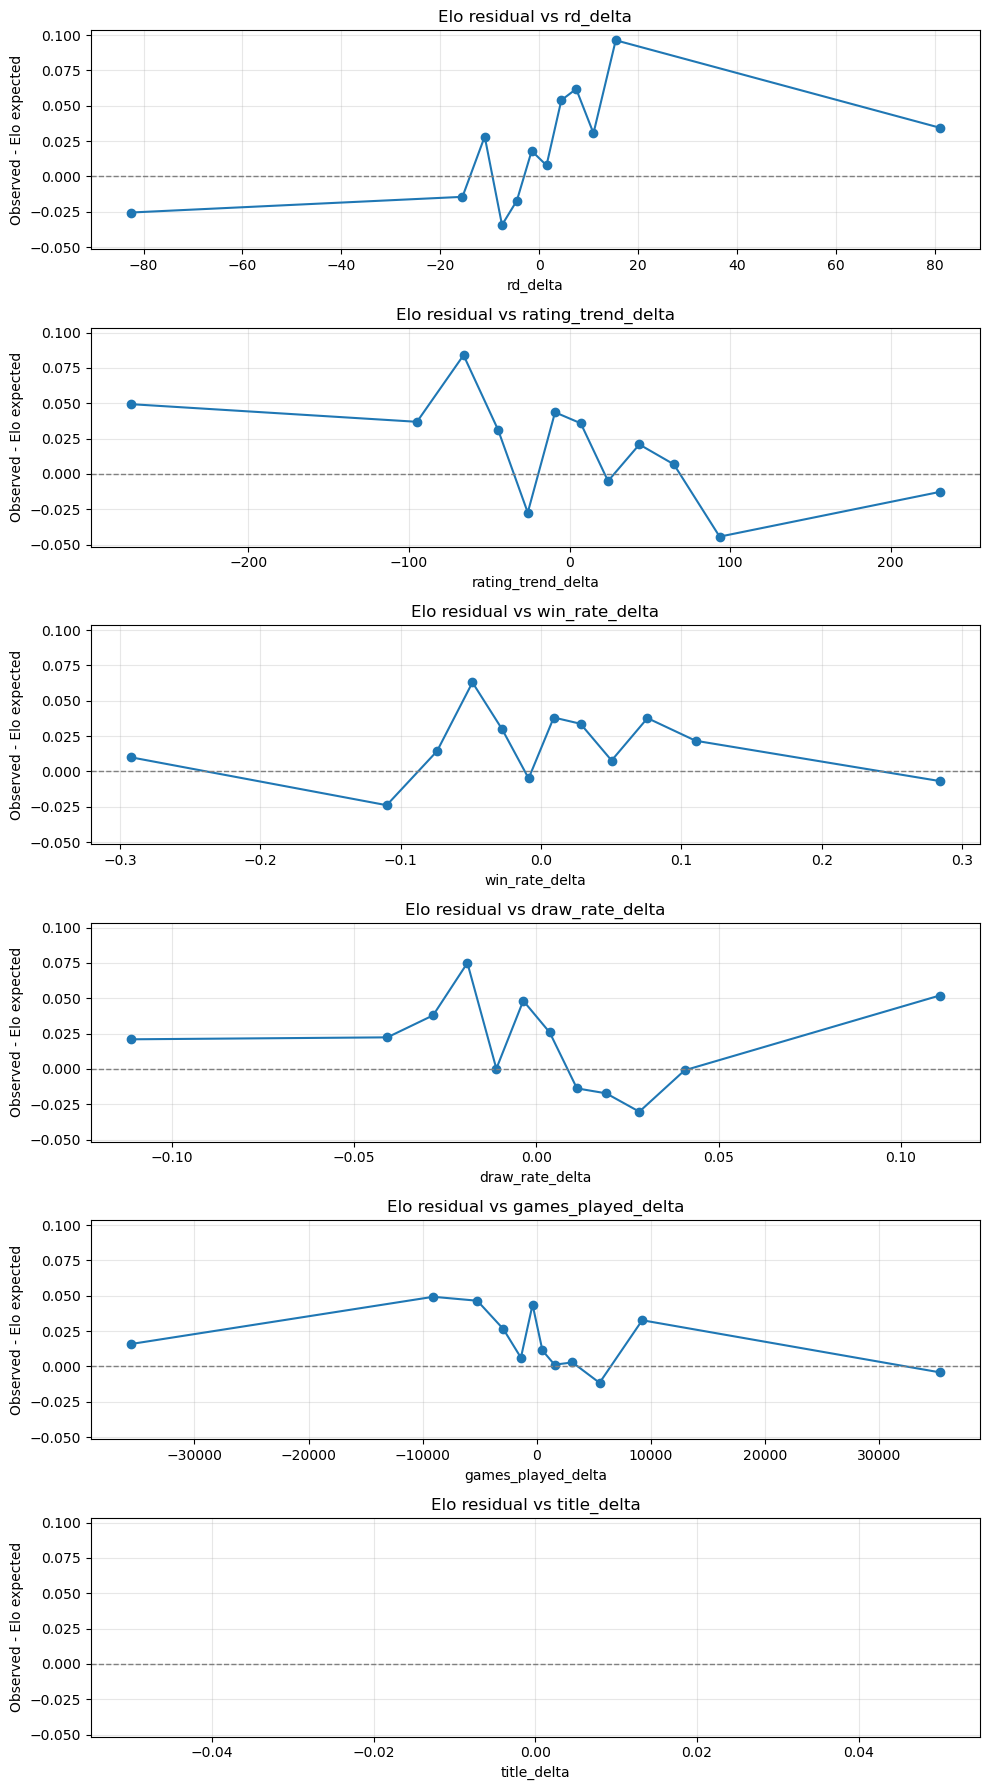

,elo_residual
elo_residual,1.000000
rd_delta,0.064433
win_rate_delta,-0.000963
games_played_delta,-0.014710
draw_rate_delta,-0.021824
rating_trend_delta,-0.059572
title_delta,NaN


In [19]:
# 3) Residual-vs-feature plots: what explains outcome beyond Elo?
resid_df = model_vis_df.copy()
resid_df["elo_expected_score"] = 1.0 / (1.0 + 10.0 ** (-resid_df["rating_delta"] / 400.0))
resid_df["elo_residual"] = resid_df["white_score"] - resid_df["elo_expected_score"]

residual_features = [
    "rd_delta",
    "rating_trend_delta",
    "win_rate_delta",
    "draw_rate_delta",
    "games_played_delta",
    "title_delta",
]
available_resid_features = [c for c in residual_features if c in resid_df.columns]

n = len(available_resid_features)
fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, max(3 * n, 6)), sharey=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, available_resid_features):
    tmp = resid_df[[col, "elo_residual"]].dropna().copy()
    if tmp.empty:
        ax.set_title(f"{col} (no data)")
        continue

    # Quantile bins for robust trend visualization.
    try:
        tmp["x_bin"] = pd.qcut(tmp[col], q=12, duplicates="drop")
    except ValueError:
        tmp["x_bin"] = pd.cut(tmp[col], bins=12)

    agg = tmp.groupby("x_bin", observed=False)["elo_residual"].agg(["mean", "count"]).reset_index()
    agg = agg[agg["count"] >= 10].copy()

    if hasattr(agg["x_bin"], "cat"):
        interval_to_mid = {
            interval: float((interval.left + interval.right) / 2)
            for interval in agg["x_bin"].cat.categories
        }
        agg["x_mid"] = agg["x_bin"].map(interval_to_mid).astype(float)
    else:
        agg["x_mid"] = np.arange(len(agg))

    ax.plot(agg["x_mid"], agg["mean"], marker="o")
    ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"Elo residual vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Observed - Elo expected")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

resid_corr = (
    resid_df[available_resid_features + ["elo_residual"]]
    .corr(numeric_only=True)[["elo_residual"]]
    .sort_values("elo_residual", ascending=False)
)
resid_corr

In [20]:
# Key EDA findings:
# - rating-difference features carry the strongest baseline signal
# - draw is the hardest class and motivates class-balanced evaluation
# - RD and residual diagnostics motivate additional draw-specific features

## Submission takeaway

This notebook supports the modeling story used in the submission:

- Rating-difference features provide the strongest baseline signal.
- Draw is materially harder than win/loss and needs explicit treatment in model design and evaluation.
- The exploration motivates class-fair selection metrics (`balanced_accuracy`, `macro_f1`, draw recall) and the later two-stage modeling approach.